# Tratamento de Dados

## A importância do tratamento de dados

O tratamento de dados é o processo de limpar, transformar e organizar os dados para que possam ser analisados e usados de forma eficaz. Em Machine Learning, dados de alta qualidade são essenciais para construir modelos precisos e confiáveis. 

Por que o tratamento de dados é crucial:

* __Precisão do modelo__ - Dados limpos e consistentes levam a modelos mais precisos.
* __Desempenho otimizado__ - Dados bem tratados reduzem o ruído e destacam os padrões relevantes, melhorando o desempenho do modelo.
* __Insights confiáveis__ - A análise de dados tratados fornece insights mais confiáveis e significativos.
* __Eficiência__ - Dados organizados e estruturados facilitam a análise e o desenvolvimento de modelos.

Em séries temporais, o tratamento de dados é ainda mais crítico devido à sua natureza sequencial e à presença de padrões temporais. Garantir que os dados estejam livres de ruído, valores ausentes e outliers é fundamental para extrair informações valiosas e fazer previsões precisas.

## Importação de Dados

A importação de dados é o ponto de partida para qualquer projeto de análise de dados ou Machine Learning. A capacidade de carregar dados de diversas fontes é fundamental para trabalhar com conjuntos de dados variados. A biblioteca Pandas, oferece métodos flexíveis para importar dados de diferentes formatos.

Neste notebook, vamos explorar duas formas comuns de importação de dados:

### 1. Importação de arquivos CSV

Arquivos CSV (Comma-Separated Values) são um formato amplamente utilizado para armazenar dados tabulares. O Pandas simplifica a importação de arquivos CSV com a função `read_csv()`.

### 2. Importação de dados financeiros com yfinance

Para dados financeiros de séries temporais, a biblioteca yfinance é uma excelente opção. Esta biblioteca permite baixar dados históricos de ações, índices e outras informações financeiras diretamente do Yahoo Finance.  
Este método já foi demostrado anteriormente e vai ser o método "padrão" neste projecto.


In [1]:
# Importação das bibliotecas gerais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importar dados de um ficheiro csv e guardar o dataset num dataframe
df = pd.read_csv('./Datasets/APPLE_dataset.csv')

# Apresentação das 5 primeiras linhas do dataframe
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,72.79602813720703,72.85662080131382,71.5453946624551,71.79988089307743,135480400
3,2020-01-03,72.08829498291016,72.85176099103282,71.86289207131898,72.0204315021118,146322800
4,2020-01-06,72.6627197265625,72.7014999191191,70.95400956000329,71.20607711333845,118387200


In [3]:
# Importar dados do site Yahoo Finance e guardar o dataset num dataframe
import yfinance as yf

# Download dos dados históricos da ação da Apple (AAPL)
apple_dataset = yf.download('AAPL', start='2020-01-01', end='2023-10-27')

# Apresentação das 5 primeiras linhas do dataframe
apple_dataset.head() # type: ignore

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.716064,72.776591,71.466805,71.721011,135480400
2020-01-03,72.009117,72.771745,71.783962,71.941328,146322800
2020-01-06,72.582893,72.621631,70.876060,71.127851,118387200
2020-01-07,72.241554,72.849231,72.021238,72.592601,108872000
2020-01-08,73.403648,73.706279,71.943759,71.943759,132079200


## Diferenças na Importação de Dados: CSV vs. yfinance

Ao importar dados de CSV e yfinance, notamos:

* __Formato da Data__ - CSV pode ter datas como texto ou NaN; yfinance usa índice datetime, ideal para séries temporais;
* __Valores Numéricos__ - Pequenas variações nos valores (preços, volume) entre as fontes;
* __Organização__ - yfinance organiza dados com data como índice; CSV pode ter dados menos organizados, como colunas repetidas;
* __Valores NaN__ - Ficheiros csv podem conter valores NaN que dificultam a manipulação dos dados.

Estas diferenças podem afetar análises futuras, exigindo atenção à consistência e manipulação temporal dos dados.

## Limpeza de Dados

Dados brutos frequentemente contêm falhas como, valores ausentes, erros, inconsistências e ruídos. A limpeza de dados é o processo de identificar e corrigir esses problemas, garantindo que os dados estejam prontos para análise e modelagem.

Por que a limpeza é fundamental:

* __Precisão das análises__ - Dados limpos geram resultados confiáveis;
* __Melhor desempenho dos modelos__ - Modelos treinados com dados limpos são mais precisos e generalizam melhor;
* __Redução de bias__ - A limpeza ajuda a mitigar o bias* introduzido por dados inconsistentes;
* __Eficiência__ - Dados limpos facilitam a análise e reduzem o tempo gasto em correções posteriores.

Em resumo, a limpeza de dados é um passo crucial para extrair insights valiosos e construir modelos de Machine Learning eficazes.  

__Nota:__ Bias, ou viés, é um conceito fundamental em estatística, análise de dados e ciência de dados que se refere a uma tendência sistemática que pode distorcer os resultados de um estudo ou análise.

## Imperfeições Comuns em Dados Brutos e Como Limpá-las

Dados brutos frequentemente apresentam imperfeições que podem comprometer a qualidade das análises e modelos de Machine Learning. As principais imperfeições incluem:

* __Valores Ausentes (NaNs)__ - Dados em falta em algumas células.
* __Outliers__ - Valores extremos que se desviam significativamente do restante dos dados.
* __Dados Duplicados__ - Linhas ou registros repetidos.
* __Inconsistências__ - Formatos de dados diferentes, erros de digitação, etc.

In [4]:
# Valores Ausentes (NaNs)

# Criar DataFrame com NaNs
data = {'A': [1, 2, np.nan, 4], 'B': [5, np.nan, 7, 8]}
df = pd.DataFrame(data)

# Detectar NaNs
print("Valores NaN:\n", df.isnull())

# Remover linhas com NaNs
df_dropna = df.dropna()
print("\nDataFrame após remover NaNs:\n", df_dropna)

# Preencher NaNs com a média
df_fillna_mean = df.fillna(df.mean())
print("\nDataFrame após preencher NaNs com a média:\n", df_fillna_mean)

# preencher NaNs com o valor anterior
df_fillna_ffill = df.ffill()
print("\nDataFrame após preencher NaNs com o valor anterior:\n", df_fillna_ffill)

Valores NaN:
        A      B
0  False  False
1  False   True
2   True  False
3  False  False

DataFrame após remover NaNs:
      A    B
0  1.0  5.0
3  4.0  8.0

DataFrame após preencher NaNs com a média:
           A         B
0  1.000000  5.000000
1  2.000000  6.666667
2  2.333333  7.000000
3  4.000000  8.000000

DataFrame após preencher NaNs com o valor anterior:
      A    B
0  1.0  5.0
1  2.0  5.0
2  2.0  7.0
3  4.0  8.0


In [5]:
'''O método IQR (Intervalo Interquartil) identifica outliers calculando
a diferença entre o terceiro e o primeiro quartil de um conjunto de dados 
e definindo limites (superior e inferior) para determinar quais valores se desviam 
significativamente da distribuição central.'''

# DataFrame de exemplo com outliers
data = {'C': [-100, 1, 2, 3, 100]}
df_outliers = pd.DataFrame(data)

# Detectar outliers com o método IQR (Interquartile Range)
Q1 = df_outliers['C'].quantile(0.25)
Q3 = df_outliers['C'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_outliers[(df_outliers['C'] < limite_inferior) | (df_outliers['C'] > limite_superior)]
print("Outliers:\n", outliers)

# Remover outliers
df_outliers_cleaned = df_outliers[~((df_outliers['C'] < limite_inferior) | (df_outliers['C'] > limite_superior))]
print("\nDataFrame após remover outliers:\n", df_outliers_cleaned)

Outliers:
      C
0 -100
4  100

DataFrame após remover outliers:
    C
1  1
2  2
3  3


In [6]:
# DataFrame de exemplo com duplicados
data = {'D': [1, 2, 2, 3]}
df_duplicates = pd.DataFrame(data)

# Detectar duplicados
print("Duplicados:\n", df_duplicates.duplicated())

# Remover duplicados
df_duplicates_cleaned = df_duplicates.drop_duplicates()
print("\nDataFrame após remover duplicados:\n", df_duplicates_cleaned)

Duplicados:
 0    False
1    False
2     True
3    False
dtype: bool

DataFrame após remover duplicados:
    D
0  1
1  2
3  3


In [7]:
# DataFrame de exemplo com inconsistências
data = {'E': ['apple', 'Apple', 'banana', 'orange']}
df_inconsistencies = pd.DataFrame(data)

# Corrigir inconsistências (convertendo valores para minúsculas)
df_inconsistencies['E'] = df_inconsistencies['E'].str.lower()
print("DataFrame após corrigir inconsistências:\n", df_inconsistencies)

DataFrame após corrigir inconsistências:
         E
0   apple
1   apple
2  banana
3  orange


## Transformação de dados

A transformação de dados é um passo crucial no pré-processamento de dados para Machine Learning, especialmente em séries temporais. O objetivo principal é converter os dados brutos em um formato mais adequado para análise e modelagem, otimizando o desempenho dos algoritmos e a precisão das previsões.

Objetivos da Transformação de Dados:

* __Melhorar a qualidade dos dados__ - Corrigir inconsistências, normalizar escalas e suavizar variações;
* __Extrair informações relevantes__ - Criar novas features que capturem padrões e tendências importantes;
* __Preparar os dados para modelos específicos__ - Ajustar o formato dos dados às necessidades de cada algoritmo.

### Métodos de Transformação de Dados:

#### Resampling: 
- Ajusta a frequência de uma série temporal, agregando ou interpolando dados para criar uma nova série com uma frequência diferente (ex: de diário para mensal);
- Útil para analisar tendências de longo prazo ou reduzir o ruído;
- Métodos comuns: média, soma, mediana.

In [8]:
# Exemplo do método Resampling

# Para reproduzir os mesmos números aleatórios
np.random.seed(42)

# Criação de uma série temporal: Frequência diária; índice é igual a um datetime;
# Tamanho de 1000 entradas de valores aleatórios com uma distribuição normal.
data = pd.Series(np.random.randn(1000), index=pd.date_range('2023-01-01', periods=1000))

# Resampling para frequência mensal (final do mês), calculando a média
monthly_mean = data.resample('ME').mean()

monthly_mean.head()

2023-01-31   -0.201488
2023-02-28   -0.143168
2023-03-31    0.043938
2023-04-30   -0.020252
2023-05-31   -0.083815
Freq: ME, dtype: float64

#### Transformações Matemáticas de Dados

As transformações matemáticas de dados desempenham um papel crucial no pré-processamento de dados para análise e modelagem, especialmente em séries temporais. Elas permitem ajustar a escala, distribuição e forma dos dados, tornando-os mais adequados para algoritmos de Machine Learning e para a extração de insights significativos.

* **Estabilização da Variância:** Transformações como a logarítmica podem reduzir a variância em dados com tendências exponenciais ou variações bruscas, facilitando a modelagem.
* **Normalização da Distribuição:** Muitas técnicas de Machine Learning assumem que os dados seguem uma distribuição normal. Transformações podem ajudar a aproximar os dados dessa distribuição.
* **Melhoria do Desempenho do Modelo:** Dados transformados podem melhorar a precisão e a estabilidade dos modelos, especialmente aqueles sensíveis à escala dos dados.
* **Extração de Padrões:** Transformações podem revelar padrões ocultos nos dados, facilitando a identificação de tendências e sazonalidades.

Em resumo, as transformações matemáticas são uma ferramenta essencial no arsenal de um cientista de dados, permitindo otimizar a qualidade dos dados e melhorar o desempenho dos modelos.

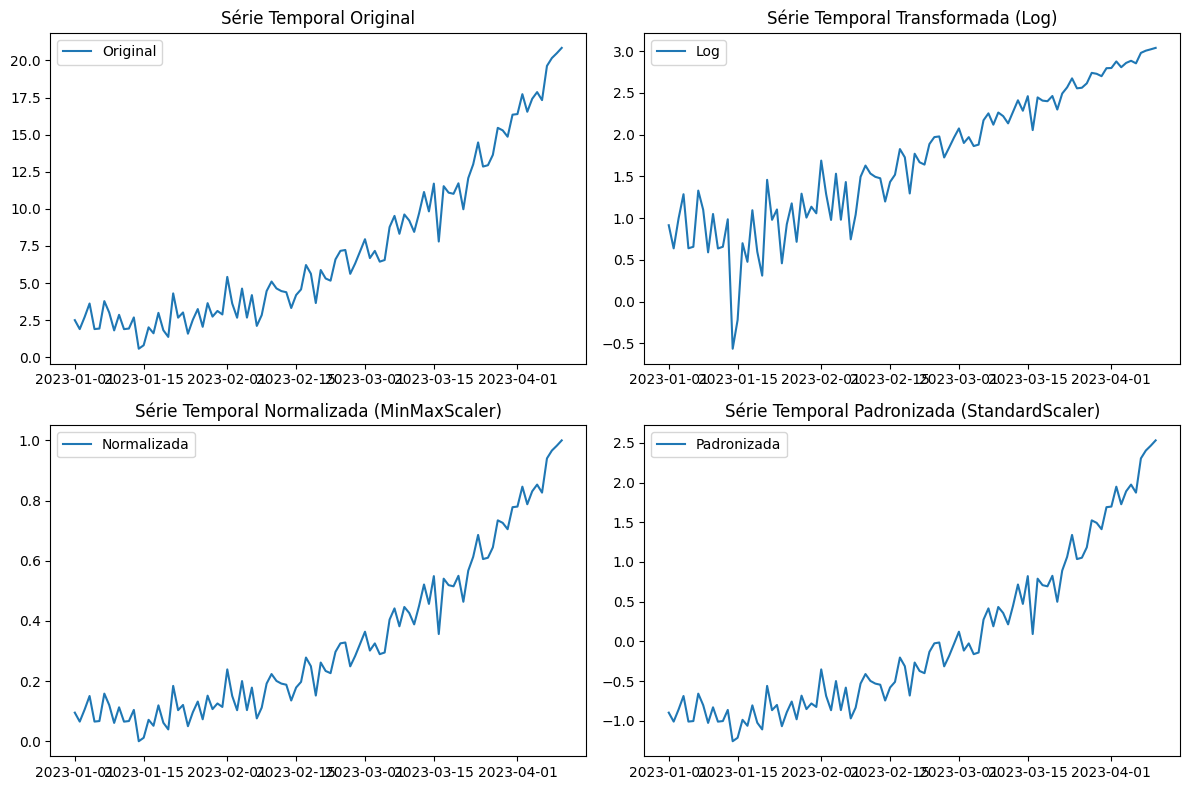

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Série temporal de exemplo (com tendência exponencial e valores próximos de zero)
np.random.seed(42)
data = pd.Series(np.exp(np.linspace(0, 3, 100)) + np.random.randn(100) + 1, 
                 index=pd.date_range('2023-01-01', periods=100))

# Ajustar a figura
plt.figure(figsize=(12, 8))

# Gráfico 1: Série Original
plt.subplot(2, 2, 1)
plt.plot(data, label='Original')
plt.title('Série Temporal Original')
plt.legend()

# Gráfico 2: Transformação Logarítmica
data_log = np.log(data)
plt.subplot(2, 2, 2)
plt.plot(data_log, label='Log')
plt.title('Série Temporal Transformada (Log)')
plt.legend()

# Gráfico 3: Normalização (MinMaxScaler)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data.values.reshape(-1, 1)) # type: ignore
data_normalized = pd.Series(data_normalized.flatten(), index=data.index)
plt.subplot(2, 2, 3)
plt.plot(data_normalized, label='Normalizada')
plt.title('Série Temporal Normalizada (MinMaxScaler)')
plt.legend()

# Gráfico 4: Padronização (StandardScaler)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data.values.reshape(-1, 1)) # type: ignore
data_standardized = pd.Series(data_standardized.flatten(), index=data.index)
plt.subplot(2, 2, 4)
plt.plot(data_standardized, label='Padronizada')
plt.title('Série Temporal Padronizada (StandardScaler)')
plt.legend()

plt.tight_layout()
plt.show()

#### Análise dos Gráficos de Transformação

Com base nos gráficos, podemos observar as seguintes características e transformações aplicadas à série temporal original:

__Série Temporal Original:__

* Apresenta uma tendência de crescimento ao longo do tempo;
* Exibe padrões sazonais, com flutuações regulares;
* A escala dos dados varia significativamente.

__Série Temporal Transformada (Log):__

* A transformação logarítmica suaviza a tendência de crescimento;
* A variância da série torna-se mais constante;
* O padrão sazonal permanece visível.

__Série Temporal Normalizada (MinMaxScaler):__

* Os dados são escalados para o intervalo \[0, 1];
* A forma da série original é preservada, mas a escala é alterada;
* Esta transformação é útil para algoritmos sensíveis à escala dos dados.

__Série Temporal Padronizada (StandardScaler):__

* Os dados são padronizados para ter média 0 e desvio padrão 1;
* A forma da série é preservada, mas a escala e a localização são modificadas;
* Esta transformação é útil para algoritmos que assumem dados normalmente distribuídos.

__Observações:__

* As transformações matemáticas alteram a escala e a distribuição dos dados, mas mantêm a forma geral da série temporal;
* A escolha da transformação depende do objetivo da análise e dos requisitos do algoritmo de Machine Learning;
* A transformação logarítmica é eficaz para estabilizar a variância e suavizar tendências exponenciais;
* A normalização e a padronização são úteis para ajustar a escala dos dados para algoritmos específicos.

#### Criação de Novas Features (Feature Engineering)

A criação de novas features (Feature Engineering) é um passo crucial no pré-processamento de séries temporais para Machine Learning. O objetivo é gerar novas variáveis a partir dos dados existentes, capturando padrões temporais e sazonais relevantes para a modelagem.

Técnicas Comuns de Feature Engineering:

* __Lags (Valores Desfasados)__ - Representam os valores anteriores da série temporal. Úteis para capturar a dependência temporal dos dados;
* __Médias Móveis__ - Suavizam o ruído e destacam as tendências. Úteis para analisar padrões de longo prazo;
* __Features Sazonais__ - Capturam padrões recorrentes nos dados, como dia da semana, mês do ano ou hora do dia.

__Exemplo:__

No exemplo abaixo, vai ser criado novas features a partir de uma série temporal original:

* Lags de 1, 3 e 7 dias;
* Médias móveis com janelas de 3 e 7 dias;
* Dia da semana.

Estas novas features podem ajudar a melhorar o desempenho dos modelos de Machine Learning, capturando diferentes aspectos da série temporal.

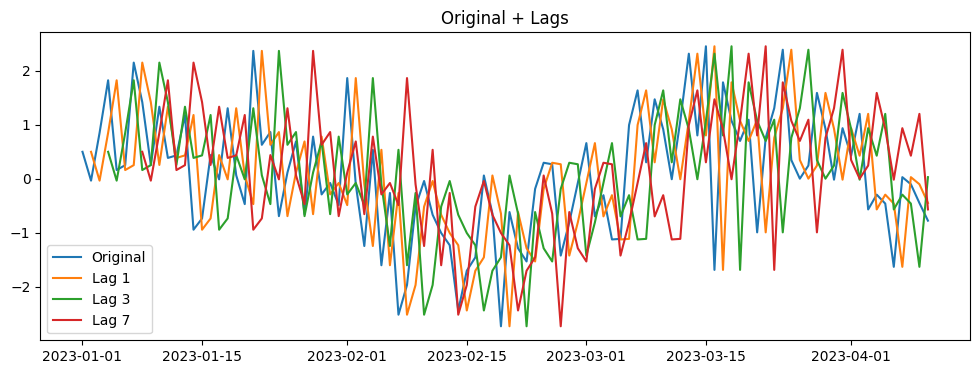

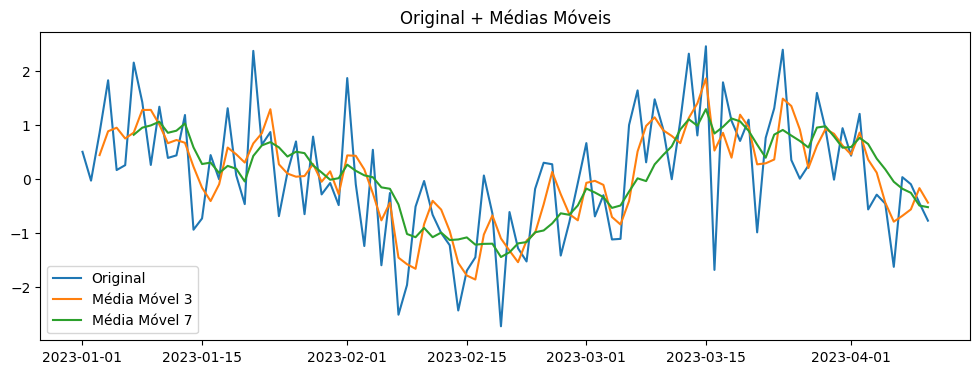

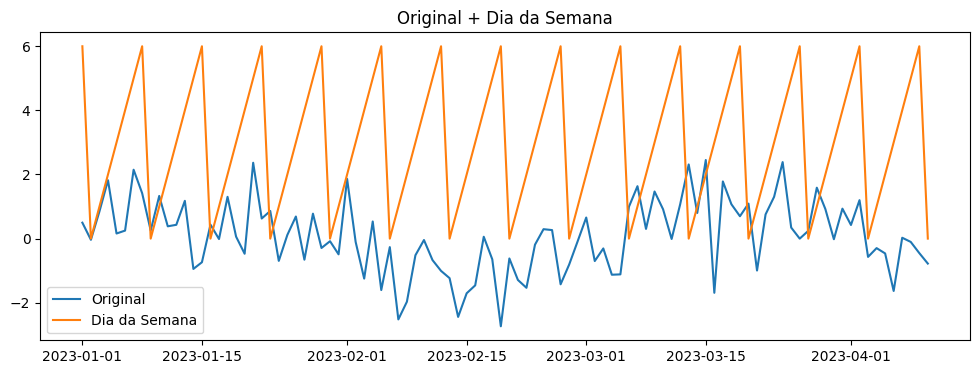

In [10]:
# Cria uma série temporal de exemplo
np.random.seed(42)
data = pd.Series(np.sin(np.linspace(0, 10, 100)) + np.random.randn(100),
                 index=pd.date_range('2023-01-01', periods=100))

# Converte a série temporal para um DataFrame
data = data.to_frame(name='Original')

# Criação de features de lags (valores defasados)
lags = [1, 3, 7]  # Lags de 1, 3 e 7 dias
for lag in lags:
    data[f'lag_{lag}'] = data['Original'].shift(lag)

# Criação de features de médias móveis
window_sizes = [3, 7]  # Janelas de 3 e 7 dias
for window in window_sizes:
    data[f'MA_{window}'] = data['Original'].rolling(window=window).mean()

# Criação de features sazonais (dia da semana)
data['dayofweek'] = data.index.dayofweek # type: ignore

# Gráfico 1: Original + Lags
plt.figure(figsize=(12, 4))
plt.plot(data['Original'], label='Original')
plt.plot(data['lag_1'], label='Lag 1')
plt.plot(data['lag_3'], label='Lag 3')
plt.plot(data['lag_7'], label='Lag 7')
plt.title('Original + Lags')
plt.legend()
plt.show()

# Gráfico 2: Original + Médias Móveis
plt.figure(figsize=(12, 4))
plt.plot(data['Original'], label='Original')
plt.plot(data['MA_3'], label='Média Móvel 3')
plt.plot(data['MA_7'], label='Média Móvel 7')
plt.title('Original + Médias Móveis')
plt.legend()
plt.show()

# Gráfico 3: Original + Dia da Semana
plt.figure(figsize=(12, 4))
plt.plot(data['Original'], label='Original')
plt.plot(data['dayofweek'], label='Dia da Semana')
plt.title('Original + Dia da Semana')
plt.legend()
plt.show()

## Conclusão

Este notebook apresenta um conjunto de etapas para o tratamento de dados essencial em séries temporais financeiras. O processo começou com a importação e exploração inicial dos dados, identificando valores ausentes e possíveis outliers.

Foram aplicadas técnicas como:
- Preenchimento de valores ausentes com o método forward fill (`ffill`),
- Conversão e indexação da coluna de datas para facilitar operações temporais,
- Reamostragem semanal para suavizar variações diárias,
- Remoção de outliers com base no intervalo interquartil (IQR),
- Normalização dos dados com `MinMaxScaler`, preparando o dataset para futuras análises ou modelação.

Estas etapas asseguram que os dados estejam mais limpos, consistentes e adequados para utilização em tarefas de Machine Learning. Um tratamento de dados cuidadoso contribui para a extração de padrões mais robustos e melhora a performance de modelos preditivos.